# Image / mask pairing check

Groups images in `data.images_dir` with their matching mask in `data.masks_dir` (same
pairing logic as `fiberseg.dataset.find_pairs`), shows each matched pair side by side,
and lists every image that has **no** matching mask.

Edit the `CONFIG_PATH` (or the manual overrides below it) to point at your data, then
run all cells.

## Interactive display backend

The single-pair keyboard labeling tool further down needs an interactive matplotlib
backend to receive key presses. Install it once with `pip install ipympl`, then run the
cell below before any other plotting cell in this notebook.

In [1]:
%matplotlib widget

import matplotlib.pyplot as plt

# Free up 'g' / 'G', which matplotlib binds to grid-toggle by default, so the
# labeling tool below can use them as keyboard shortcuts.
plt.rcParams["keymap.grid"] = []
plt.rcParams["keymap.grid_minor"] = []

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import yaml
from PIL import Image

IMG_EXTENSIONS = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}

## Config

Loads `data.images_dir` / `data.masks_dir` / `data.image_glob` / `data.mask_pattern` from a
project YAML config. Set `CONFIG_PATH = None` to skip this and fill in the manual overrides
below instead.

In [2]:
CONFIG_PATH = "../configs/simple_sweep.yaml"

# Manual overrides -- leave as None to use the value from CONFIG_PATH.
IMAGES_DIR = "c:/Users/lababr/Desktop/Sigurd/Current Training Material - fibers only - Preproc/Images"
MASKS_DIR = "c:/Users/lababr/Desktop/Sigurd/Current Training Material - fibers only - Preproc/Masks"
IMAGE_GLOB = None
MASK_PATTERN = None

if CONFIG_PATH is not None:
    with open(CONFIG_PATH) as f:
        _data_cfg = yaml.safe_load(f)["data"]
else:
    _data_cfg = {}

images_dir = Path(IMAGES_DIR or _data_cfg["images_dir"])
masks_dir = Path(MASKS_DIR or _data_cfg["masks_dir"])
image_glob = IMAGE_GLOB or _data_cfg.get("image_glob", "*.tif")
mask_pattern = MASK_PATTERN or _data_cfg.get("mask_pattern", "{stem}_mask.tif")

print(f"images_dir:   {images_dir.resolve()}")
print(f"masks_dir:    {masks_dir.resolve()}")
print(f"image_glob:   {image_glob!r}")
print(f"mask_pattern: {mask_pattern!r}")

images_dir:   C:\Users\lababr\Desktop\Sigurd\Current Training Material - fibers only - Preproc\Images
masks_dir:    C:\Users\lababr\Desktop\Sigurd\Current Training Material - fibers only - Preproc\Masks
image_glob:   '*.tif'
mask_pattern: '{stem}_mask.tif'


## Pair images with masks

Mirrors `fiberseg.dataset.find_pairs`: glob `images_dir` for `image_glob`, drop anything
whose stem ends in `_mask` (those are ground-truth masks, not inputs), then for each
remaining image compute the expected mask filename from `mask_pattern` and check whether
it exists in `masks_dir`.

In [3]:
def find_pairs_and_missing(images_dir: Path, masks_dir: Path, image_glob: str, mask_pattern: str):
    image_paths = sorted(
        p for p in images_dir.glob(image_glob)
        if p.suffix.lower() in IMG_EXTENSIONS and not p.stem.endswith("_mask")
    )

    pairs = []
    unmatched = []

    for img in image_paths:
        mask_name = mask_pattern.format(stem=img.stem, suffix=img.suffix, name=img.name)
        mask = masks_dir / mask_name
        if mask.exists():
            pairs.append((img, mask))
        else:
            unmatched.append(img)

    return pairs, unmatched


pairs, unmatched = find_pairs_and_missing(images_dir, masks_dir, image_glob, mask_pattern)

print(f"{len(pairs)} image/mask pairs found")
print(f"{len(unmatched)} images have no matching mask")

298 image/mask pairs found
1 images have no matching mask


## Matched pairs, quick overview

Static grid of all matched pairs. Set `MAX_PAIRS_TO_SHOW = None` to display all of them.
For labeling individual pairs as good/bad, use the interactive tool further down instead.

In [5]:
unmatched_df = pd.DataFrame({
    "image": [p.name for p in unmatched],
    "expected_mask": [mask_pattern.format(stem=p.stem, suffix=p.suffix, name=p.name) for p in unmatched],
})
unmatched_df

,image,expected_mask
0,A52_15.00kV_0.10nA_33.7nm_1.00µs_027.tif,A52_15.00kV_0.10nA_33.7nm_1.00µs_027_mask.tif


## Label pairs one at a time (keyboard: G = good, B = bad)

Shows one image/mask/overlay triplet at a time. Click the figure once so it has focus,
then press:

- `g` — label the pair **good**, advance to the next unlabeled pair
- `b` — label the pair **bad**, advance to the next unlabeled pair
- `u` — undo the last label and jump back to it

Labels are saved incrementally to `pair_labels.csv` next to this notebook, so you can
stop and resume later — already-labeled pairs are skipped automatically. Set
`RELABEL_ALL = True` below to go through every pair again from scratch.

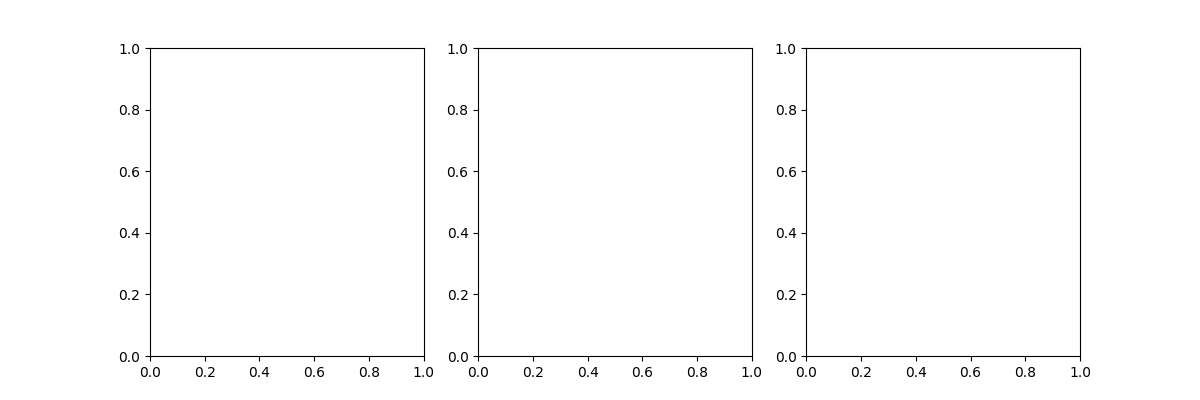

In [4]:
RELABEL_ALL = False
LABELS_CSV = Path("pair_labels.csv")

if LABELS_CSV.exists() and not RELABEL_ALL:
    _labels_df = pd.read_csv(LABELS_CSV)
    labels = dict(zip(_labels_df["image"], _labels_df["label"]))
else:
    labels = {}

order = [img_path.name for img_path, _ in pairs]
pair_by_name = {img_path.name: (img_path, mask_path) for img_path, mask_path in pairs}
history = []


def save_labels():
    pd.DataFrame({"image": list(labels.keys()), "label": list(labels.values())}).to_csv(
        LABELS_CSV, index=False
    )


def next_unlabeled(start):
    i = start
    while i < len(order) and order[i] in labels:
        i += 1
    return i


state = {"idx": next_unlabeled(0)}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
try:
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
except AttributeError:
    pass  # non-widget backend, e.g. inline -- toolbar controls don't apply


def read_gray(path: Path) -> np.ndarray:
    if path.suffix.lower() in {".tif", ".tiff"}:
        arr = tifffile.imread(path)
    else:
        arr = np.asarray(Image.open(path).convert("L"))
    if arr.ndim == 3:
        arr = arr[..., :3].mean(axis=-1)
    return arr


def normalize_for_display(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)
    if img.size == 0:
        return img
    lo, hi = np.percentile(img, [1, 99.5])
    if hi <= lo:
        return np.zeros_like(img)
    return np.clip((img - lo) / (hi - lo), 0, 1)


def show_pairs(pairs, limit=None):
    shown = pairs if limit is None else pairs[:limit]
    for img_path, mask_path in shown:
        image = normalize_for_display(read_gray(img_path))
        mask = read_gray(mask_path) > 0

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(image, cmap="gray")
        axes[0].set_title(img_path.name)
        axes[1].imshow(mask, cmap="gray")
        axes[1].set_title(mask_path.name)
        axes[2].imshow(image, cmap="gray")
        axes[2].imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.5)
        axes[2].set_title("overlay")
        for ax in axes:
            ax.axis("off")
        fig.tight_layout()
        plt.show()

    if limit is not None and len(pairs) > limit:
        print(f"... {len(pairs) - limit} more pair(s) not shown (raise MAX_PAIRS_TO_SHOW to see them)")




def render():
    for ax in axes:
        ax.clear()
        ax.axis("off")

    n_good = sum(v == "good" for v in labels.values())
    n_bad = sum(v == "bad" for v in labels.values())

    if state["idx"] >= len(order):
        fig.suptitle(f"All pairs labeled -- {n_good} good, {n_bad} bad out of {len(order)}.")
        fig.canvas.draw_idle()
        return

    name = order[state["idx"]]
    img_path, mask_path = pair_by_name[name]
    image = normalize_for_display(read_gray(img_path))
    mask = read_gray(mask_path) > 0

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title(img_path.name)
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(mask_path.name)
    axes[2].imshow(image, cmap="gray")
    axes[2].imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.5)
    axes[2].set_title("overlay")
    for ax in axes:
        ax.axis("off")

    already = f"  (already labeled: {labels[name]})" if name in labels else ""
    fig.suptitle(
        f"{state['idx'] + 1}/{len(order)}  {name}{already}   |   "
        f"g=good  b=bad  u=undo   |   {n_good} good, {n_bad} bad so far"
    )
    fig.canvas.draw_idle()


def label_current(label):
    if state["idx"] >= len(order):
        return
    name = order[state["idx"]]
    labels[name] = label
    history.append(name)
    save_labels()
    state["idx"] = next_unlabeled(state["idx"] + 1)
    render()


def undo():
    if not history:
        return
    name = history.pop()
    labels.pop(name, None)
    save_labels()
    state["idx"] = order.index(name)
    render()


def on_key(event):
    if event.key == "g":
        label_current("good")
    elif event.key == "b":
        label_current("bad")
    elif event.key == "u":
        undo()



In [ ]:

fig.canvas.mpl_connect("key_press_event", on_key)
render()

## Review labeled pairs

Re-reads `pair_labels.csv`, so this can be run any time -- including after closing and
reopening the notebook -- without re-running the labeling tool.

In [ ]:
labels_df = pd.read_csv(LABELS_CSV) if LABELS_CSV.exists() else pd.DataFrame(columns=["image", "label"])
print(labels_df["label"].value_counts().to_string())

bad_df = labels_df[labels_df["label"] == "bad"].reset_index(drop=True)
bad_df

## Matched pairs, side by side

Set `MAX_PAIRS_TO_SHOW = None` to display all of them.

In [ ]:
MAX_PAIRS_TO_SHOW = 20


show_pairs(pairs, MAX_PAIRS_TO_SHOW)

## Rate pairs: Mask Quality, Filter Loading, Asbestos

Opens a single native, resizable window showing one **image / overlay / mask** triplet
at a time (like the `g`/`b`/`u` keyboard labeler further up), with the rating controls
built into that same window below the image:

- **Mask Quality** `[0, 5]`, 5 = best segmentation quality
- **Filter Loading**: `very low / low / medium / high / very high`
- **Asbestos** present `[True/False]`
- **< Prev / Save / Next >** buttons

**Prev and Next both auto-save the current pair's values before moving** (Save is only
needed if you want to persist without navigating, e.g. right before closing the window).
Reopening the notebook resumes at the first not-yet-rated pair, with every already-rated
pair's values pre-filled if you navigate back to it.

The window opens maximized and its own toolbar gives real zoom/pan — drag to zoom, scroll
or the magnifier tool to zoom in/out. Click the figure once so it has keyboard focus, then
press **`r`** to reset pan/zoom back to the original fit-to-image view on all three panels
at once.

Reuses `read_gray`/`normalize_for_display` and the `pairs` list already defined above.

**Note:** the cell below switches the matplotlib backend to `tk` for the rest of this
kernel session (needed for a real OS window). If you want to go back to the embedded
`g`/`b`/`u` labeler afterward, re-run the `%matplotlib widget` cell near the top first.

In [5]:
%matplotlib tk

import tkinter as tk
from tkinter import ttk

# Free up 'r' (and 'h'), which matplotlib's toolbar binds to "reset view" by
# default, so QualityRater's own 'r' handler is the only thing that fires --
# its version resets all three panels at once and stays correct across the
# ax.clear()+redraw each pair does (the toolbar's own history doesn't).
plt.rcParams["keymap.home"] = []

RATINGS_CSV = Path("pair_quality_ratings.csv")
RATING_COLUMNS = ["mask_quality", "filter_loading", "asbestos"]
FILTER_LOADING_LEVELS = ["very low", "low", "medium", "high", "very high"]

if RATINGS_CSV.exists():
    _ratings_df = pd.read_csv(RATINGS_CSV).set_index("image")
    ratings = {
        name: {col: row[col] for col in RATING_COLUMNS} for name, row in _ratings_df.iterrows()
    }
else:
    ratings = {}

rating_order = [img_path.name for img_path, _ in pairs]
rating_pair_by_name = {img_path.name: (img_path, mask_path) for img_path, mask_path in pairs}
print(f"{len(ratings)}/{len(rating_order)} pair(s) already rated in {RATINGS_CSV.resolve()}")


def save_ratings():
    rows = [{"image": name, **values} for name, values in ratings.items()]
    pd.DataFrame(rows, columns=["image", *RATING_COLUMNS]).to_csv(RATINGS_CSV, index=False)


class QualityRater:
    def __init__(self, order, pair_by_name, values):
        self.order = order
        self.pair_by_name = pair_by_name
        self.values = values
        self.idx = self._first_unrated_index()
        self._home_xlim = [None, None, None]
        self._home_ylim = [None, None, None]

        # figsize 15% bigger than the original (16, 6) -- there was spare gray
        # space in the window once the control panel moved below the image.
        self.fig, self.axes = plt.subplots(1, 3, figsize=(18.4, 6.9))
        self.fig.canvas.manager.set_window_title("Rate image/mask pairs")
        self.fig.canvas.mpl_connect("key_press_event", self._on_key)
        self.window = self.fig.canvas.manager.window
        try:
            self.window.state("zoomed")  # start maximized (Windows Tk)
        except AttributeError:
            pass  # non-Tk backend -- window sizing controls don't apply

        # Native Tk control panel, packed into the same window below the
        # figure canvas/toolbar (matplotlib's FigureManagerTk already packed
        # those with side=TOP, so this claims the remaining space at the bottom).
        panel = ttk.Frame(self.window, padding=8)
        panel.pack(side=tk.BOTTOM, fill=tk.X)

        self.status_var = tk.StringVar()
        ttk.Label(panel, textvariable=self.status_var, font=("", 10, "bold")).pack(
            side=tk.TOP, anchor="w"
        )

        form = ttk.Frame(panel)
        form.pack(side=tk.TOP, fill=tk.X, pady=6)

        self.quality_var = tk.IntVar(value=0)
        tk.Scale(
            form, from_=0, to=5, resolution=1, orient=tk.HORIZONTAL,
            variable=self.quality_var, label="Mask Quality", length=220,
        ).grid(row=0, column=0, sticky="w", padx=(0, 24))

        self.loading_var = tk.StringVar(value=FILTER_LOADING_LEVELS[0])
        loading_frame = ttk.LabelFrame(form, text="Filter Loading")
        loading_frame.grid(row=0, column=1, sticky="w", padx=(0, 24))
        for level in FILTER_LOADING_LEVELS:
            ttk.Radiobutton(
                loading_frame, text=level, value=level, variable=self.loading_var
            ).pack(side=tk.LEFT, padx=4, pady=4)

        self.asbestos_var = tk.BooleanVar(value=False)
        ttk.Checkbutton(
            form, text="Asbestos present", variable=self.asbestos_var
        ).grid(row=0, column=2, sticky="w")

        buttons = ttk.Frame(panel)
        buttons.pack(side=tk.TOP, fill=tk.X)
        ttk.Button(buttons, text="< Prev", command=self._on_prev).pack(side=tk.LEFT)
        ttk.Button(buttons, text="Save", command=self._on_save).pack(side=tk.LEFT, padx=8)
        ttk.Button(buttons, text="Next >", command=self._on_next).pack(side=tk.LEFT)

    def _first_unrated_index(self) -> int:
        for i, name in enumerate(self.order):
            if name not in self.values:
                return i
        return len(self.order) - 1  # everything already rated -- open on the last pair

    def _load_current_into_widgets(self) -> None:
        existing = self.values.get(self.order[self.idx], {})
        self.quality_var.set(int(existing.get("mask_quality", 0)))
        self.loading_var.set(existing.get("filter_loading", FILTER_LOADING_LEVELS[0]))
        self.asbestos_var.set(bool(existing.get("asbestos", False)))

    def _capture_current_from_widgets(self) -> None:
        name = self.order[self.idx]
        self.values[name] = {
            "mask_quality": self.quality_var.get(),
            "filter_loading": self.loading_var.get(),
            "asbestos": self.asbestos_var.get(),
        }

    def _render(self) -> None:
        self._load_current_into_widgets()
        name = self.order[self.idx]
        img_path, mask_path = self.pair_by_name[name]
        already = "  (already rated)" if name in self.values else ""
        self.status_var.set(f"{self.idx + 1}/{len(self.order)}  {name}{already}")

        for ax in self.axes:
            ax.clear()
            ax.axis("off")

        image = normalize_for_display(read_gray(img_path))
        mask = read_gray(mask_path) > 0
        self.axes[0].imshow(image, cmap="gray", interpolation="nearest")
        self.axes[0].set_title(img_path.name)
        self.axes[1].imshow(image, cmap="gray", interpolation="nearest")
        self.axes[1].imshow(
            np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.5, interpolation="nearest"
        )
        self.axes[1].set_title("overlay")
        self.axes[2].imshow(mask, cmap="gray", interpolation="nearest")
        self.axes[2].set_title(mask_path.name)
        for ax in self.axes:
            ax.axis("off")

        # Remember each panel's fit-to-image view so 'r' can restore it later,
        # even after the user has panned/zoomed away from it.
        self._home_xlim = [ax.get_xlim() for ax in self.axes]
        self._home_ylim = [ax.get_ylim() for ax in self.axes]

        self.fig.canvas.draw_idle()

    def _on_key(self, event) -> None:
        if event.key not in ("r", "R"):
            return
        for ax, xlim, ylim in zip(self.axes, self._home_xlim, self._home_ylim):
            if xlim is not None:
                ax.set_xlim(xlim)
                ax.set_ylim(ylim)
        self.fig.canvas.draw_idle()

    def _on_save(self) -> None:
        self._capture_current_from_widgets()
        save_ratings()
        self._render()

    def _on_prev(self) -> None:
        self._capture_current_from_widgets()
        save_ratings()
        self.idx = max(0, self.idx - 1)
        self._render()

    def _on_next(self) -> None:
        self._capture_current_from_widgets()
        save_ratings()
        self.idx = min(len(self.order) - 1, self.idx + 1)
        self._render()


quality_rater = QualityRater(rating_order, rating_pair_by_name, ratings)
quality_rater._render()

213/298 pair(s) already rated in C:\Users\lababr\Desktop\Sigurd\fiber_unet_trainer\notebooks\pair_quality_ratings.csv
